<a href="https://colab.research.google.com/github/CodeBrecher/Electrocardiogram_Signals_for_Arrhythmia_Detection/blob/main/Untitled10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wfdb scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 89.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import wfdb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Import 6 different ML Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
print("Fetching dataset with STRICT Patient-Wise Splitting...")

train_records = ['100', '119', '200'] # Patients the model learns from
test_records = ['214']                # Patient the model has NEVER seen

window_size = 150
valid_beats = {'N': 0, 'V': 1}

def extract_patient_data(records_list):
    X_list, y_list = [], []
    for record_name in records_list:
        record = wfdb.rdrecord(record_name, pn_dir='mitdb')
        annotation = wfdb.rdann(record_name, 'atr', pn_dir='mitdb')

        sig = record.p_signal[:, 0]
        peaks = annotation.sample
        symbols = annotation.symbol

        for peak, symbol in zip(peaks, symbols):
            if symbol in valid_beats:
                if peak - window_size > 0 and peak + window_size < len(sig):
                    beat = sig[peak - window_size : peak + window_size]
                    X_list.append(beat)
                    y_list.append(valid_beats[symbol])
    return np.array(X_list), np.array(y_list)

X_train_1D, y_train = extract_patient_data(train_records)
X_test_1D, y_test = extract_patient_data(test_records)

print(f"Extracted {len(X_train_1D)} training beats and {len(X_test_1D)} testing beats.")

Fetching dataset with STRICT Patient-Wise Splitting...
Extracted 6793 training beats and 256 testing beats.


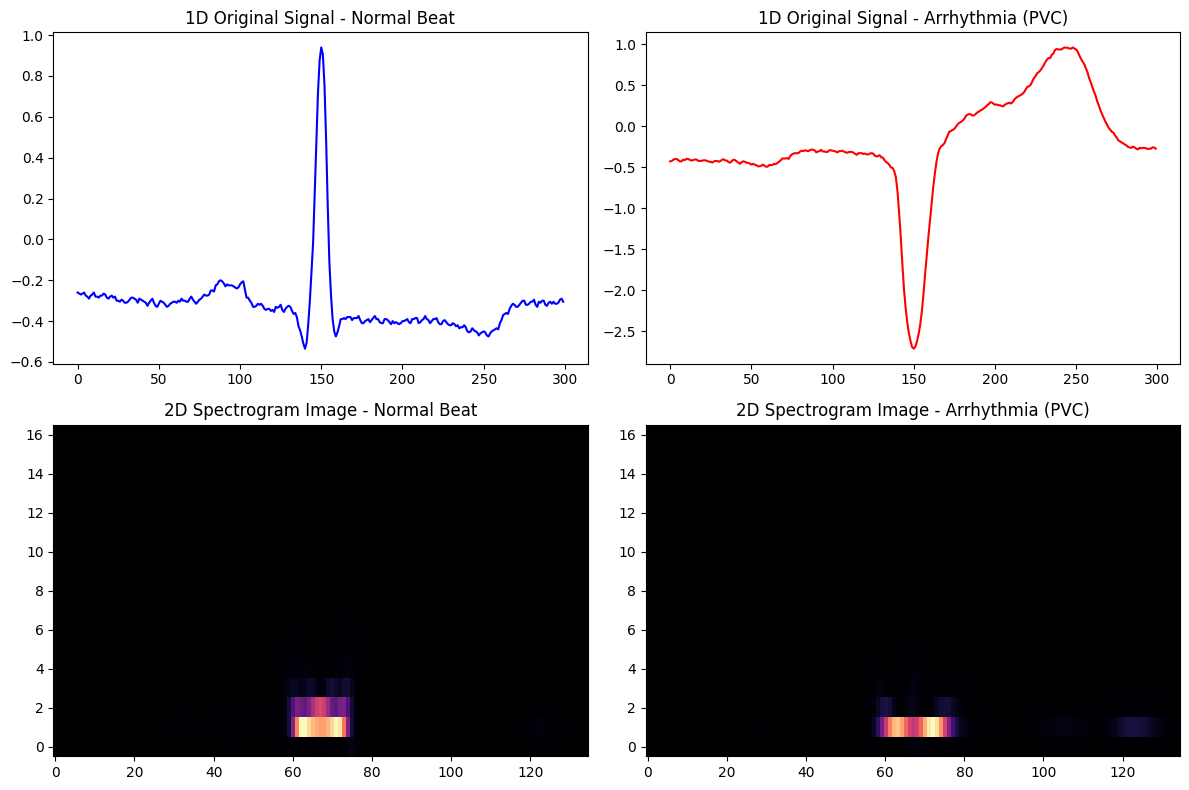

In [ ]:
# Find one normal beat and one arrhythmia (PVC) beat
idx_normal = np.where(y_train == 0)[0][0]
idx_arrhythmia = np.where(y_train == 1)[0][0]

beat_normal = X_train_1D[idx_normal]
beat_arrhythmia = X_train_1D[idx_arrhythmia]

# Generate Spectrograms for them
f_n, t_n, Sxx_n = signal.spectrogram(beat_normal, fs=360, nperseg=32, noverlap=30)
f_a, t_a, Sxx_a = signal.spectrogram(beat_arrhythmia, fs=360, nperseg=32, noverlap=30)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1D Signals
axes[0,0].plot(beat_normal, color='blue')
axes[0,0].set_title("1D Original Signal - Normal Beat")
axes[0,1].plot(beat_arrhythmia, color='red')
axes[0,1].set_title("1D Original Signal - Arrhythmia (PVC)")

# Plot 2D Spectrograms
axes[1,0].imshow(Sxx_n, aspect='auto', cmap='magma', origin='lower')
axes[1,0].set_title("2D Spectrogram Image - Normal Beat")
axes[1,1].imshow(Sxx_a, aspect='auto', cmap='magma', origin='lower')
axes[1,1].set_title("2D Spectrogram Image - Arrhythmia (PVC)")

plt.tight_layout()
plt.show()

In [ ]:
print("Converting all signals to 2D Spectrograms...")

def convert_to_2d(X_1D_data):
    X_2D = []
    for beat in X_1D_data:
        _, _, Sxx = signal.spectrogram(beat, fs=360, nperseg=32, noverlap=30)
        X_2D.append(Sxx)
    return np.array(X_2D)

X_train_2D = convert_to_2d(X_train_1D)
X_test_2D = convert_to_2d(X_test_1D)

# Flatten for Scikit-Learn Traditional Models
X_train_flat = X_train_2D.reshape(X_train_2D.shape[0], -1)
X_test_flat = X_test_2D.reshape(X_test_2D.shape[0], -1)

# Dictionary to store all model accuracies
results = {}

print("Data ready for training!")

Converting all signals to 2D Spectrograms...
Data ready for training!


In [ ]:
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_flat, y_train)
results['Random Forest'] = accuracy_score(y_test, rf.predict(X_test_flat))
print(f"Done! Accuracy: {results['Random Forest']*100:.2f}%")

Training Random Forest...
Done! Accuracy: 96.09%


In [ ]:
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_flat, y_train)
results['Logistic Regression'] = accuracy_score(y_test, lr.predict(X_test_flat))
print(f"Done! Accuracy: {results['Logistic Regression']*100:.2f}%"),

Training Logistic Regression...
Done! Accuracy: 8.98%


(None,)

In [ ]:
print("Training Support Vector Machine...")
svm = SVC(kernel='rbf')
svm.fit(X_train_flat, y_train)
results['SVM'] = accuracy_score(y_test, svm.predict(X_test_flat))
print(f"Done! Accuracy: {results['SVM']*100:.2f}%")

Training Support Vector Machine...
Done! Accuracy: 78.52%


In [ ]:
print("Training K-Nearest Neighbors...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_flat, y_train)
results['KNN'] = accuracy_score(y_test, knn.predict(X_test_flat))
print(f"Done! Accuracy: {results['KNN']*100:.2f}%")

Training K-Nearest Neighbors...
Done! Accuracy: 78.91%


In [ ]:
print("Training Naive Bayes...")
nb = GaussianNB()
nb.fit(X_train_flat, y_train)
results['Naive Bayes'] = accuracy_score(y_test, nb.predict(X_test_flat))
print(f"Done! Accuracy: {results['Naive Bayes']*100:.2f}%")

Training Naive Bayes...
Done! Accuracy: 89.06%


In [ ]:
print("Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
gb.fit(X_train_flat, y_train)
results['Gradient Boosting'] = accuracy_score(y_test, gb.predict(X_test_flat))
print(f"Done! Accuracy: {results['Gradient Boosting']*100:.2f}%")

Training Gradient Boosting...
Done! Accuracy: 99.22%


In [ ]:
print("--- Training ADVANCED 2D Convolutional Neural Network ---")

# 1. PyTorch Tensors
X_train_tensor = torch.tensor(X_train_2D, dtype=torch.float32).unsqueeze(1).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test_2D, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)

# 2. Handle Class Imbalance (CRITICAL for MIT-BIH)
# Calculate the ratio of Normal to Arrhythmia beats
num_normal = (y_train == 0).sum()
num_arrhythmia = (y_train == 1).sum()
imbalance_ratio = num_normal / num_arrhythmia

# Tell the loss function to care way more about Arrhythmia (Class 1)
class_weights = torch.tensor([1.0, imbalance_ratio], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# 3. Advanced CNN Architecture
class AdvancedSpectrogramCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1: 32 Filters
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)

        # Block 2: 64 Filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)

        # Block 3: 128 Filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Adaptive pooling forces the output to be exactly 4x8, no matter the exact input size
        self.adapool = nn.AdaptiveAvgPool2d((4, 8))

        # Fully Connected Layers with Dropout for regularization
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 4 * 8, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.adapool(F.relu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

# Initialize the upgraded model
cnn_model = AdvancedSpectrogramCNN().to(device)
# slightly lower learning rate for deeper network
optimizer = optim.Adam(cnn_model.parameters(), lr=0.0005)

# 4. Training Loop (Increased Epochs)
epochs = 15 # A deeper network needs more time to learn
cnn_model.train()

for epoch in range(epochs):
    total_loss = 0
    for data, target in train_loader:
        optimizer.zero_grad()
        output = cnn_model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Print progress every 3 epochs
    if (epoch + 1) % 3 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

# 5. Evaluation
cnn_model.eval()
with torch.no_grad():
    preds = torch.max(cnn_model(X_test_tensor), 1)[1]
    cnn_acc = (preds == y_test_tensor).sum().item() / len(y_test_tensor)

print(f"\nDone! Advanced CNN Accuracy: {cnn_acc*100:.2f}%")

#Class Weights:
#Deeper Filters:
#Dropout (50%):

#Batch Normalization:

--- Training ADVANCED 2D Convolutional Neural Network ---
Epoch 3/15 | Loss: 0.0298
Epoch 6/15 | Loss: 0.0167
Epoch 9/15 | Loss: 0.0103
Epoch 12/15 | Loss: 0.0130
Epoch 15/15 | Loss: 0.0073

Done! Advanced CNN Accuracy: 98.05%


Generating Final Comparison Chart...


/tmp/ipykernel_6483/3805243562.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracies, y=model_names, palette='magma')


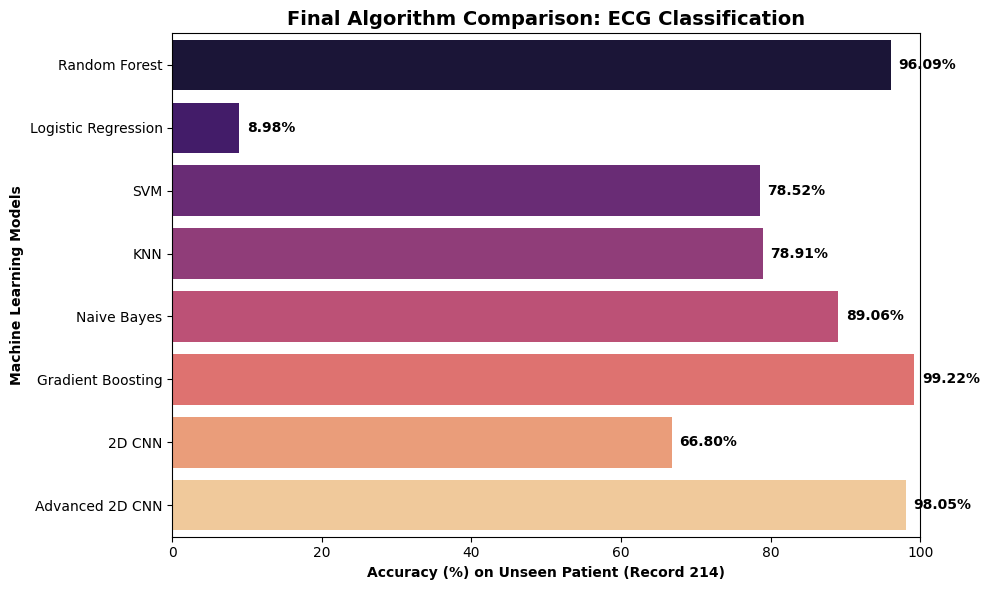

In [ ]:
print("Generating Final Comparison Chart...")

# 1. Add the new Advanced CNN accuracy to our dictionary
# (This ensures it shows up in the chart alongside the traditional models)
results['Advanced 2D CNN'] = cnn_acc

# 2. Plot the final results
plt.figure(figsize=(10, 6))
model_names = list(results.keys())
accuracies = [acc * 100 for acc in results.values()]

# Using 'magma' to match our spectrogram visuals!
sns.barplot(x=accuracies, y=model_names, palette='magma')

# Formatting the chart
plt.xlabel('Accuracy (%) on Unseen Patient (Record 214)', fontweight='bold')
plt.ylabel('Machine Learning Models', fontweight='bold')
plt.title('Final Algorithm Comparison: ECG Classification', fontsize=14, fontweight='bold')
plt.xlim(0, 100)

# Add the exact percentage text to the end of each bar
for index, value in enumerate(accuracies):
    plt.text(value + 1, index, f'{value:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()